# Integration Benchmarking and Visualization (scGPT vs scVI)

Author: Yuxuan Xu

Description:
This notebook benchmarks different embedding methods (scGPT, fine-tuned scGPT,
and scVI) using scIB metrics and visualizes their performance.

The evaluation focuses on two key aspects:
- Biological conservation (preservation of cell type structure)
- Batch correction (removal of technical variation)

Main steps:
- Compute scIB benchmark metrics for selected embeddings
- Extract and clean evaluation results
- Organize metrics into biological and batch-related groups
- Visualize results using a bubble heatmap

Goals:
- Quantitatively compare embedding quality across methods
- Identify trade-offs between biological signal and batch correction
- Support conclusions from qualitative UMAP analysis

Inputs:
- AnnData object with embeddings:
    - scGPT (`X_scGPT`)
    - fine-tuned scGPT (`X_scGPT_finetuned`)
    - scVI (`X_scVI`)
- Cell metadata (e.g. batch, cell type)

Outputs:
- Benchmark results table (CSV)
- Bubble heatmap visualization of metrics

Notes:
- Larger and darker markers indicate better performance
- Metrics are grouped into biological conservation and batch correction
- Total score summarizes overall integration quality
"""

In [1]:
import scanpy as sc
import anndata as ad

/home/ubuntu/miniforge/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [15]:
!pip install scib_metrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 23.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.5/82.5 MB 157.8 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 134.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 102.6 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/12 [numpy]
      Successfully uninstalled numpy-1.26.4━━━━━━━━━━━━━━━━━━━  1/12 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [scib_metrics] [jax]ib]n-it-py]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scatlastb-utils 0.0.1 requires numpy<2, but you have numpy 2.2.6 which is incompatible.


In [2]:
adata1 = sc.read_h5ad("retina_scgpt_cell_emb_finetuned_umap.h5ad")

In [3]:
print(adata1.obsm.keys())

KeysView(AxisArrays with keys: X_scGPT, X_scGPT_finetuned, X_scVI, X_umap, X_umap_scgpt_ft)


In [4]:
print(adata1.obs.columns.tolist())


['reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'reported_diseases', 'sex_ontology_term_id', 'RGC_celltype_number', 'study_name', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'sampleid', 'cell_type', 'assay', 'disease', 'sex', 'tissue

In [5]:
import scanpy as sc
import scib_metrics
from scib_metrics.benchmark import Benchmarker
import pandas as pd

# ==========================================
# Step 1: Specify embeddings to evaluate (exclude UMAP)
# ==========================================
embed_keys = [
    "X_scGPT",
    "X_scGPT_finetuned",
    "X_scVI"
]

# ==========================================
# Step 2: Initialize scIB Benchmarker
# ==========================================
print("Initializing Benchmarker...")

bm = Benchmarker(
    adata1,
    batch_key="sample_id",     # source of batch effects (change to "sampleid" if needed)
    label_key="cell_type",     # ground truth cell type labels
    embedding_obsm_keys=embed_keys,
    n_jobs=-1                  # use all available CPU cores
)

# ==========================================
# Step 3: Run benchmarking metrics
# ==========================================
print("Computing biological conservation and batch correction metrics...")
bm.benchmark()

# ==========================================
# Step 4: Extract and format results
# ==========================================
results_df = bm.get_results(min_max_scale=False)

# Rename index column to 'id' (required for downstream plotting)
results_df = results_df.reset_index().rename(columns={"index": "id"})

# Rename columns for clearer presentation
results_df = results_df.rename(columns={
    "Silhouette label": "ASW_Label",
    "Silhouette batch": "ASW_Batch",
    "Isolated label F1": "Isolated_Label_F1",
    "Graph connectivity": "Graph_Connectivity"
})

print("\nComputation finished. Results preview:")
print(results_df.head())

# Save results to CSV
results_df.to_csv("scgpt_scvi_metrics.csv", index=False)
print("\n✅ Results saved to scgpt_scvi_metrics.csv")

/home/ubuntu/miniforge/envs/scanpy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


正在初始化 Benchmarker...
开始计算 Bio Conservation 和 Batch Correction 指标...


/home/ubuntu/miniforge/envs/scanpy/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
Metrics:   0%|        | 0/10 [00:00<?, ?it/s, Bio conservation: isolated_labels]
Metrics:  10%| | 1/10 [03:25<30:45, 205.02s/it, Bio conservation: isolated_label
Metrics:  10%| | 1/10 [03:25<30:45, 205.02s/it, Bio conservation: nmi_ari_cluste
Metrics:  20%|▏| 2/10 [03:35<12:02, 90.30s/it, Bio conservation: nmi_ari_cluster
Metrics:  20%|▏| 2/10 [03:35<12:02, 90.30s/it, Bio conservation: silhouette_labe
Metrics:  30%|▎| 3/10 [06:58<16:34, 142.05s/it, Bio conservation: silhouette_lab
Metrics:  70%|▋| 7/10 [07:16<01:25, 28.65s/it, Batch correction: kbet_per_label]
Metrics:  70%|▋| 7/10 [07:16<01:25, 28.65s/it, 


计算完成！你的新数据结果如下：
           Embedding   Isolated labels        KMeans NMI        KMeans ARI  \
0            X_scGPT          0.516617          0.009349          0.011492   
1  X_scGPT_finetuned          0.512446          0.012061          0.015943   
2             X_scVI          0.568049          0.487655          0.330703   
3        Metric Type  Bio conservation  Bio conservation  Bio conservation   

          ASW_Label             cLISI              BRAS             iLISI  \
0          0.487907          0.466778          0.681432          0.080371   
1          0.492042          0.483189          0.702929          0.081666   
2          0.525272          0.994616          0.912271          0.091004   
3  Bio conservation  Bio conservation  Batch correction  Batch correction   

               KBET Graph_Connectivity    PCR comparison Batch correction  \
0          0.493469           0.892496          0.163365         0.462227   
1          0.517753           0.899489          0.24

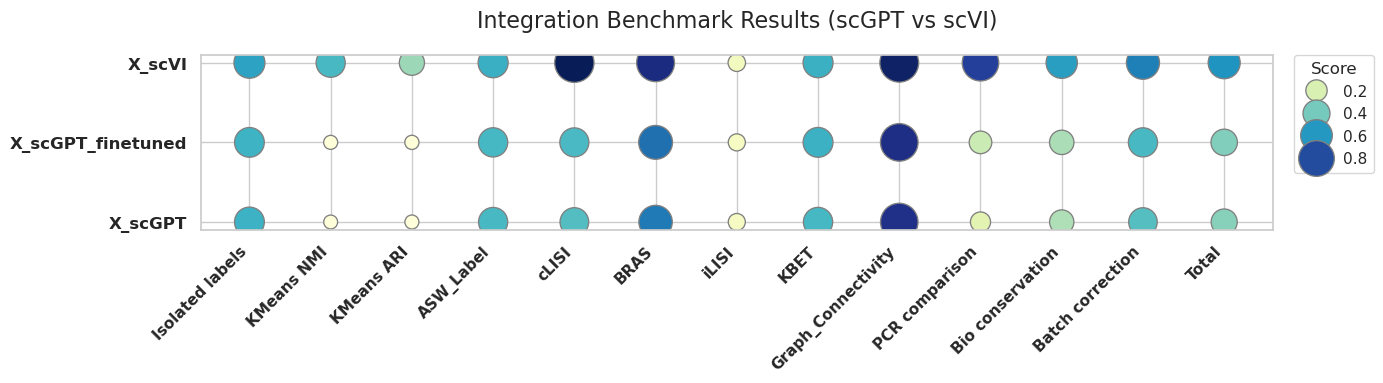

✅ 气泡热图已生成并保存！


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load benchmark results
df = pd.read_csv("scgpt_scvi_metrics.csv")

# 2. Data cleaning: remove non-numeric rows and convert to numeric
df_plot = df[df['Embedding'] != 'Metric Type'].copy()
df_plot.set_index('Embedding', inplace=True)
df_plot = df_plot.astype(float)

# 3. Sort by total score (best-performing model on top)
df_plot = df_plot.sort_values('Total', ascending=False)

# 4. Reorder columns: group related metrics together
metrics_order = [
    # Bio conservation
    'Isolated labels', 'KMeans NMI', 'KMeans ARI', 'ASW_Label', 'cLISI',
    # Batch correction
    'BRAS', 'iLISI', 'KBET', 'Graph_Connectivity', 'PCR comparison',
    # Overall scores
    'Bio conservation', 'Batch correction', 'Total'
]
df_plot = df_plot[metrics_order]

# 5. Convert from wide to long format (for plotting)
df_melt = df_plot.reset_index().melt(
    id_vars='Embedding',
    var_name='Metric',
    value_name='Score'
)

# ================= Plot =================
plt.figure(figsize=(14, 4))
sns.set_theme(style="whitegrid")

# Bubble plot: size and color both represent score
scatter = sns.scatterplot(
    data=df_melt,
    x='Metric',
    y='Embedding',
    size='Score',
    hue='Score',
    sizes=(100, 800),      # marker size range
    palette="YlGnBu",      # yellow-green-blue gradient
    edgecolor='gray'
)

# Improve layout
plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.xlabel("")
plt.ylabel("")
plt.title("Integration Benchmark Results (scGPT vs scVI)", fontsize=16, pad=20)

# Move legend outside the plot
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0.,
    title="Score"
)

plt.tight_layout()

# Save high-resolution figure
plt.savefig("integration_bubble_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Bubble heatmap generated and saved!")